In [1]:
# Cell 1: Environment setup and file check
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

# This notebook lives in "Payment Risk Engine/notebooks/", data is one level up
DATA_DIR = Path("../data")
TRAIN_PATH = DATA_DIR / "fraudTrain.csv"
TEST_PATH = DATA_DIR / "fraudTest.csv"

print("Python:", sys.version.split()[0])
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("Train file found:", TRAIN_PATH.exists())
print("Test file found:", TEST_PATH.exists())

Python: 3.12.10
numpy: 2.4.6
pandas: 3.0.3
scikit-learn: 1.9.0
Train file found: True
Test file found: True


In [2]:
# Cell 2: Load data and structural overview
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Combined rows:", len(train) + len(test))
print()

print("Columns:")
print(list(train.columns))
print()

print("Dtypes:")
print(train.dtypes)
print()

# Fraud rate in each split (is_fraud is the target: 1 = fraud, 0 = legit)
for name, df in [("train", train), ("test", test)]:
    rate = df["is_fraud"].mean()
    n_fraud = int(df["is_fraud"].sum())
    print(f"{name}: {n_fraud:,} fraud / {len(df):,} rows = {rate:.4%}")

Train shape: (1296675, 23)
Test shape: (555719, 23)
Combined rows: 1852394

Columns:
['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']

Dtypes:
Unnamed: 0                 int64
trans_date_trans_time        str
cc_num                     int64
merchant                     str
category                     str
amt                      float64
first                        str
last                         str
gender                       str
street                       str
city                         str
state                        str
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                          str
dob                          str
trans_num                    str
unix_time                  int6

In [3]:
# Cell 3: Peek at real values and per-column summary
print("First 3 rows (transposed for readability):")
print(train.head(3).T)
print()

summary = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "n_missing": train.isna().sum(),
    "pct_missing": (train.isna().mean() * 100).round(2),
    "n_unique": train.nunique(),
})
print("Per-column summary:")
print(summary)

First 3 rows (transposed for readability):
                                                      0                                  1  \
Unnamed: 0                                            0                                  1   
trans_date_trans_time               2019-01-01 00:00:18                2019-01-01 00:00:44   
cc_num                                 2703186189652095                       630423337322   
merchant                     fraud_Rippin, Kub and Mann    fraud_Heller, Gutmann and Zieme   
category                                       misc_net                        grocery_pos   
amt                                                4.97                             107.23   
first                                          Jennifer                          Stephanie   
last                                              Banks                               Gill   
gender                                                F                                  F   
street           

In [4]:
# Cell 4: Column role plan (decision record, no data changes yet)
column_roles = {
    "target": ["is_fraud"],
    "drop_identifier_or_pii": [
        "Unnamed: 0", "trans_num", "cc_num", "first", "last",
        "street", "zip", "unix_time",
    ],
    "transform_then_drop_raw": [
        "trans_date_trans_time",  # -> hour, day-of-week, month
        "dob",                    # -> age
        "lat", "long", "merch_lat", "merch_long",  # -> distance
    ],
    "candidate_features": [
        "amt", "category", "gender", "city_pop", "merchant",
        "city", "state", "job",
    ],
}

for role, cols in column_roles.items():
    print(f"{role} ({len(cols)}): {cols}")
print()

print("category values (", train["category"].nunique(), "unique ):")
print(sorted(train["category"].unique()))
print()

print("High-cardinality check:")
for c in ["merchant", "city", "state", "job"]:
    print(f"  {c}: {train[c].nunique():,} unique")

target (1): ['is_fraud']
drop_identifier_or_pii (8): ['Unnamed: 0', 'trans_num', 'cc_num', 'first', 'last', 'street', 'zip', 'unix_time']
transform_then_drop_raw (6): ['trans_date_trans_time', 'dob', 'lat', 'long', 'merch_lat', 'merch_long']
candidate_features (8): ['amt', 'category', 'gender', 'city_pop', 'merchant', 'city', 'state', 'job']

category values ( 14 unique ):
['entertainment', 'food_dining', 'gas_transport', 'grocery_net', 'grocery_pos', 'health_fitness', 'home', 'kids_pets', 'misc_net', 'misc_pos', 'personal_care', 'shopping_net', 'shopping_pos', 'travel']

High-cardinality check:
  merchant: 693 unique
  city: 894 unique
  state: 51 unique
  job: 494 unique


Train: 7,506 fraud vs 1,289,169 legit  ->  1 fraud per 172 legit
scale_pos_weight (neg/pos) = 171.75

Transaction amount ($) by class:
              count    mean     std   min     50%      90%      99%       max
is_fraud                                                                     
0         1289169.0   67.67  154.01  1.00   47.28   134.21   486.30  28948.90
1            7506.0  531.32  390.56  1.06  396.50  1024.59  1179.69   1376.04


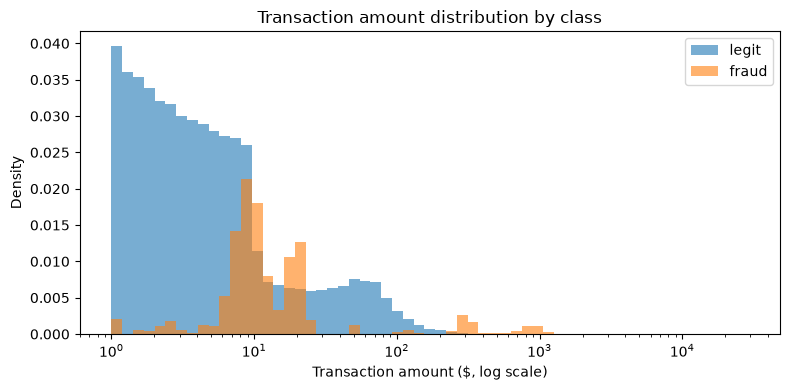

In [5]:
# Cell 5: Target imbalance and amount distribution by class
import numpy as np

# Imbalance, stated as a ratio for the report
n_pos = int(train["is_fraud"].sum())
n_neg = len(train) - n_pos
print(f"Train: {n_pos:,} fraud vs {n_neg:,} legit  ->  1 fraud per {n_neg / n_pos:.0f} legit")
print(f"scale_pos_weight (neg/pos) = {n_neg / n_pos:.2f}")
print()

# Amount summary by class
print("Transaction amount ($) by class:")
print(train.groupby("is_fraud")["amt"].describe(percentiles=[0.5, 0.9, 0.99]).round(2))

# Plot: amount distribution by class, log x-axis
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.logspace(np.log10(1), np.log10(train["amt"].max()), 60)
ax.hist(train.loc[train.is_fraud == 0, "amt"], bins=bins, alpha=0.6, density=True, label="legit")
ax.hist(train.loc[train.is_fraud == 1, "amt"], bins=bins, alpha=0.6, density=True, label="fraud")
ax.set_xscale("log")
ax.set_xlabel("Transaction amount ($, log scale)")
ax.set_ylabel("Density")
ax.set_title("Transaction amount distribution by class")
ax.legend()
plt.tight_layout()
plt.show()

Fraud rate by hour of day:
       size  mean_pct
hour                 
0     42502     1.494
1     42869     1.535
2     42656     1.465
3     42769     1.424
4     41863     0.110
5     42171     0.142
6     42300     0.095
7     42203     0.133
8     42505     0.115
9     42185     0.111
10    42271     0.095
11    42082     0.100
12    65257     0.103
13    65314     0.122
14    64885     0.133
15    65391     0.121
16    65726     0.116
17    65450     0.119
18    66051     0.123
19    65508     0.124
20    65098     0.095
21    65533     0.113
22    66982     2.883
23    67104     2.837


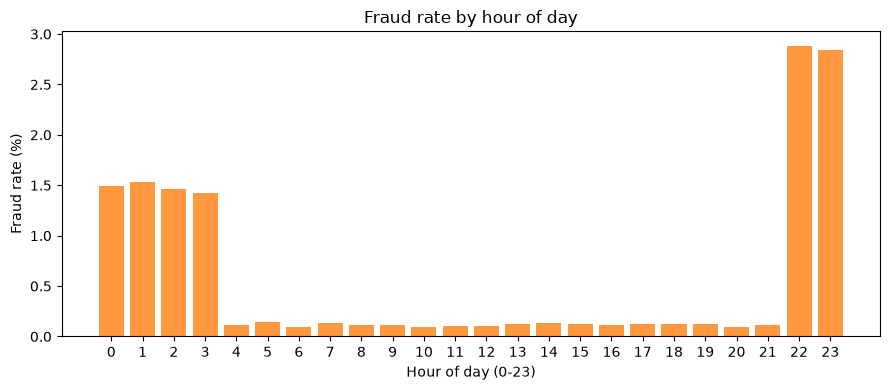

In [6]:
# Cell 6: Parse timestamp and fraud rate by hour of day
train["dt"] = pd.to_datetime(train["trans_date_trans_time"])
train["hour"] = train["dt"].dt.hour

# Fraud rate per hour (mean of is_fraud within each hour)
hourly = train.groupby("hour")["is_fraud"].agg(["mean", "size"])
hourly["mean_pct"] = (hourly["mean"] * 100).round(3)
print("Fraud rate by hour of day:")
print(hourly[["size", "mean_pct"]])

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(hourly.index, hourly["mean"] * 100, color="tab:orange", alpha=0.8)
ax.set_xlabel("Hour of day (0-23)")
ax.set_ylabel("Fraud rate (%)")
ax.set_title("Fraud rate by hour of day")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

Fraud rate by category (sorted):
                  size  mean_pct
category                        
shopping_net     97543     1.756
misc_net         63287     1.446
grocery_pos     123638     1.410
shopping_pos    116672     0.723
gas_transport   131659     0.469
misc_pos         79655     0.314
grocery_net      45452     0.295
travel           40507     0.286
entertainment    94014     0.248
personal_care    90758     0.242
kids_pets       113035     0.211
food_dining      91461     0.165
home            123115     0.161
health_fitness   85879     0.155


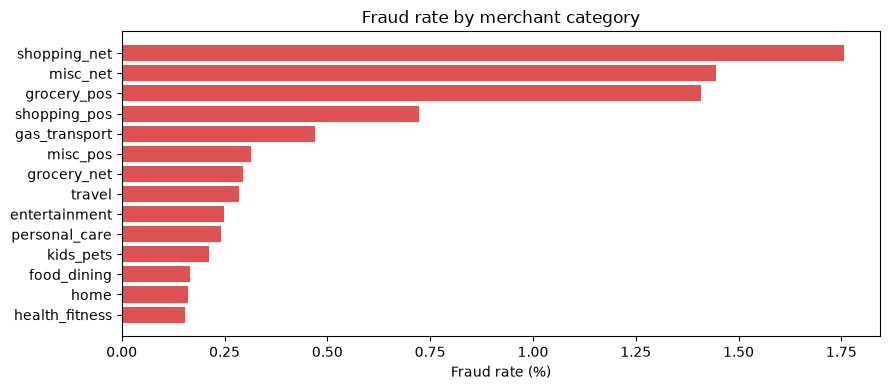

In [7]:
# Cell 7: Fraud rate by merchant category
cat = train.groupby("category")["is_fraud"].agg(["mean", "size"]).sort_values("mean", ascending=False)
cat["mean_pct"] = (cat["mean"] * 100).round(3)
print("Fraud rate by category (sorted):")
print(cat[["size", "mean_pct"]])

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(cat.index, cat["mean"] * 100, color="tab:red", alpha=0.8)
ax.set_xlabel("Fraud rate (%)")
ax.set_title("Fraud rate by merchant category")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Distance (km) by class:
              count   mean    std   min    50%     90%     99%     max
is_fraud                                                              
0         1289169.0  76.11  29.12  0.02  78.23  112.82  132.05  152.12
1            7506.0  76.27  28.75  0.74  77.93  112.75  132.04  144.52


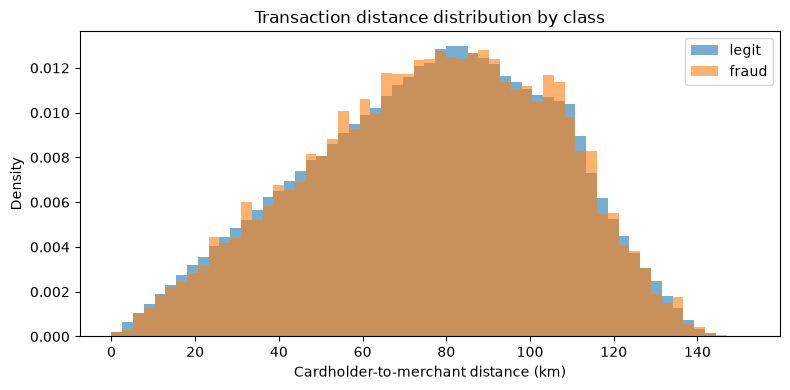

In [8]:
# Cell 8: Cardholder-to-merchant distance (Haversine) by class
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

train["distance_km"] = haversine_km(
    train["lat"], train["long"], train["merch_lat"], train["merch_long"]
)

print("Distance (km) by class:")
print(train.groupby("is_fraud")["distance_km"].describe(percentiles=[0.5, 0.9, 0.99]).round(2))

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, train["distance_km"].max(), 60)
ax.hist(train.loc[train.is_fraud == 0, "distance_km"], bins=bins, alpha=0.6, density=True, label="legit")
ax.hist(train.loc[train.is_fraud == 1, "distance_km"], bins=bins, alpha=0.6, density=True, label="fraud")
ax.set_xlabel("Cardholder-to-merchant distance (km)")
ax.set_ylabel("Density")
ax.set_title("Transaction distance distribution by class")
ax.legend()
plt.tight_layout()
plt.show() 

In [9]:
# Cell 9: Feature engineering - build the modeling table (train and test)
def build_features(df):
    out = pd.DataFrame(index=df.index)

    # Timestamp-derived features
    dt = pd.to_datetime(df["trans_date_trans_time"])
    hour = dt.dt.hour
    out["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    out["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    out["is_night"] = hour.isin([22, 23, 0, 1, 2, 3]).astype(int)
    out["day_of_week"] = dt.dt.dayofweek          # 0 = Monday
    out["month"] = dt.dt.month

    # Amount (raw + log for skew)
    out["amt"] = df["amt"].values
    out["log_amt"] = np.log1p(df["amt"].values)

    # Cardholder age at time of transaction
    dob = pd.to_datetime(df["dob"])
    out["age"] = (dt - dob).dt.days / 365.25

    # City population (numeric, used directly)
    out["city_pop"] = df["city_pop"].values

    # Low-cardinality categoricals -> one-hot
    cat = pd.get_dummies(df["category"], prefix="cat").astype(int)
    gen = pd.get_dummies(df["gender"], prefix="gender").astype(int)
    out = pd.concat([out, cat, gen], axis=1)

    return out

# Build features and targets for each split separately
X_train = build_features(train)
y_train = train["is_fraud"].values

X_test = build_features(test)
y_test = test["is_fraud"].values

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Feature columns:", list(X_train.columns))
print()
print("X_train dtypes summary:")
print(X_train.dtypes.value_counts())
print()
print("Any missing values? train:", int(X_train.isna().sum().sum()), " test:", int(X_test.isna().sum().sum()))

X_train shape: (1296675, 25)
X_test shape: (555719, 25)
Feature columns: ['hour_sin', 'hour_cos', 'is_night', 'day_of_week', 'month', 'amt', 'log_amt', 'age', 'city_pop', 'cat_entertainment', 'cat_food_dining', 'cat_gas_transport', 'cat_grocery_net', 'cat_grocery_pos', 'cat_health_fitness', 'cat_home', 'cat_kids_pets', 'cat_misc_net', 'cat_misc_pos', 'cat_personal_care', 'cat_shopping_net', 'cat_shopping_pos', 'cat_travel', 'gender_F', 'gender_M']

X_train dtypes summary:
int64      18
float64     5
int32       2
Name: count, dtype: int64

Any missing values? train: 0  test: 0


In [10]:
# Cell 10: Logistic regression baseline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Standardize features: fit on train only, apply to both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# class_weight balanced counteracts the 172:1 imbalance
logreg = LogisticRegression(max_iter=1000, class_weight="balanced")
logreg.fit(X_train_scaled, y_train)

# Predicted probabilities of fraud (column 1)
train_proba_lr = logreg.predict_proba(X_train_scaled)[:, 1]
test_proba_lr = logreg.predict_proba(X_test_scaled)[:, 1]

print("Logistic regression trained.")
print("Train fraud-probability range:", round(train_proba_lr.min(), 4), "to", round(train_proba_lr.max(), 4))
print("Test fraud-probability range:", round(test_proba_lr.min(), 4), "to", round(test_proba_lr.max(), 4))
print("Mean predicted fraud prob (test):", round(test_proba_lr.mean(), 4), "| actual test fraud rate:", round(y_test.mean(), 4))

Logistic regression trained.
Train fraud-probability range: 0.0 to 1.0
Test fraud-probability range: 0.0 to 1.0
Mean predicted fraud prob (test): 0.1369 | actual test fraud rate: 0.0039


In [11]:
# Cell 11: Baseline evaluation on the temporal test set
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    precision_score, recall_score, confusion_matrix,
)

pr_auc = average_precision_score(y_test, test_proba_lr)
roc_auc = roc_auc_score(y_test, test_proba_lr)

# Metrics at the default 0.5 threshold
pred_05 = (test_proba_lr >= 0.5).astype(int)
prec_05 = precision_score(y_test, pred_05)
rec_05 = recall_score(y_test, pred_05)
tn, fp, fn, tp = confusion_matrix(y_test, pred_05).ravel()

print("=== Logistic Regression (test set) ===")
print(f"PR-AUC (average precision): {pr_auc:.4f}   [no-skill baseline = {y_test.mean():.4f}]")
print(f"ROC-AUC:                    {roc_auc:.4f}")
print()
print("At threshold 0.50:")
print(f"  Precision: {prec_05:.4f}")
print(f"  Recall:    {rec_05:.4f}")
print(f"  Confusion matrix: TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")


=== Logistic Regression (test set) ===
PR-AUC (average precision): 0.1799   [no-skill baseline = 0.0039]
ROC-AUC:                    0.9615

At threshold 0.50:
  Precision: 0.0347
  Recall:    0.8657
  Confusion matrix: TN=501,977  FP=51,597  FN=288  TP=1,857


In [12]:
# Cell 12: Train XGBoost
from xgboost import XGBClassifier

# Imbalance ratio computed from training labels only
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos
print(f"scale_pos_weight = {spw:.2f}")

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    eval_metric="aucpr",
    n_jobs=-1,
    random_state=42,
)
xgb.fit(X_train, y_train)

test_proba_xgb = xgb.predict_proba(X_test)[:, 1]
print("XGBoost trained.")
print("Test fraud-probability range:", round(test_proba_xgb.min(), 4), "to", round(test_proba_xgb.max(), 4))

scale_pos_weight = 171.75
XGBoost trained.
Test fraud-probability range: 0.0 to 1.0


In [13]:
# %pip install xgboost shap imbalanced-learn

In [14]:
# Cell 13: XGBoost evaluation and comparison with baseline
pr_auc_xgb = average_precision_score(y_test, test_proba_xgb)
roc_auc_xgb = roc_auc_score(y_test, test_proba_xgb)

pred_05_xgb = (test_proba_xgb >= 0.5).astype(int)
prec_05_xgb = precision_score(y_test, pred_05_xgb)
rec_05_xgb = recall_score(y_test, pred_05_xgb)
tn, fp, fn, tp = confusion_matrix(y_test, pred_05_xgb).ravel()

print("=== XGBoost (test set) ===")
print(f"PR-AUC (average precision): {pr_auc_xgb:.4f}   [no-skill baseline = {y_test.mean():.4f}]")
print(f"ROC-AUC:                    {roc_auc_xgb:.4f}")
print()
print("At threshold 0.50:")
print(f"  Precision: {prec_05_xgb:.4f}")
print(f"  Recall:    {rec_05_xgb:.4f}")
print(f"  Confusion matrix: TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
print()
print("=== Comparison (PR-AUC) ===")
print(f"  Logistic Regression: {pr_auc:.4f}")
print(f"  XGBoost:             {pr_auc_xgb:.4f}")
print(f"  Improvement:         {pr_auc_xgb - pr_auc:+.4f}  ({(pr_auc_xgb/pr_auc - 1)*100:+.1f}%)")

=== XGBoost (test set) ===
PR-AUC (average precision): 0.8658   [no-skill baseline = 0.0039]
ROC-AUC:                    0.9975

At threshold 0.50:
  Precision: 0.4254
  Recall:    0.9152
  Confusion matrix: TN=550,923  FP=2,651  FN=182  TP=1,963

=== Comparison (PR-AUC) ===
  Logistic Regression: 0.1799
  XGBoost:             0.8658
  Improvement:         +0.6859  (+381.3%)


In [15]:
# Cell 14: Calibrate XGBoost probabilities (isotonic, on a held-out slice of train)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator          # changed: new in sklearn 1.6+
from sklearn.metrics import brier_score_loss

# Time-ordered split of the TRAINING data: first 80% to fit the model,
# last 20% held out to fit calibration. (Rows are already in time order.)
cut = int(len(X_train) * 0.8)
X_fit, X_cal = X_train.iloc[:cut], X_train.iloc[cut:]
y_fit, y_cal = y_train[:cut], y_train[cut:]

# Refit XGBoost on the fit portion only, using the same settings
xgb_fit = XGBClassifier(
    n_estimators=400, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
    eval_metric="aucpr", n_jobs=-1, random_state=42,
)
xgb_fit.fit(X_fit, y_fit)

# Fit isotonic calibration on the held-out slice.
# changed: wrap the fitted model in FrozenEstimator instead of cv="prefit"
calibrated = CalibratedClassifierCV(FrozenEstimator(xgb_fit), method="isotonic")
calibrated.fit(X_cal, y_cal)

# Compare calibration quality on the test set (Brier score: lower is better)
test_proba_cal = calibrated.predict_proba(X_test)[:, 1]
brier_raw = brier_score_loss(y_test, test_proba_xgb)
brier_cal = brier_score_loss(y_test, test_proba_cal)

print("Brier score (lower = better calibrated):")
print(f"  Raw XGBoost:        {brier_raw:.5f}")
print(f"  Calibrated XGBoost: {brier_cal:.5f}")
print()
print("Mean predicted prob vs actual fraud rate (test):")
print(f"  Raw:        {test_proba_xgb.mean():.4f}")
print(f"  Calibrated: {test_proba_cal.mean():.4f}")
print(f"  Actual:     {y_test.mean():.4f}")
print()
pr_auc_cal = average_precision_score(y_test, test_proba_cal)
print(f"PR-AUC after calibration: {pr_auc_cal:.4f}  (was {pr_auc_xgb:.4f} before)")

Brier score (lower = better calibrated):
  Raw XGBoost:        0.00377
  Calibrated XGBoost: 0.00119

Mean predicted prob vs actual fraud rate (test):
  Raw:        0.0108
  Calibrated: 0.0039
  Actual:     0.0039

PR-AUC after calibration: 0.8476  (was 0.8658 before)


Assumed false-positive cost: $5 per blocked legit transaction
Optimal threshold (min expected cost): 0.029
  Total cost at optimal threshold: $51,272
  Recall at optimal:    0.9287
  Precision at optimal: 0.3188

For reference, at threshold 0.50: cost $169,762, recall 0.7385, precision 0.8742


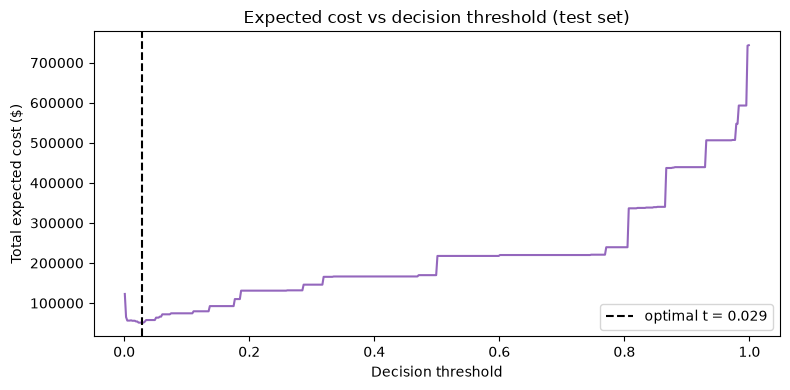

In [16]:
# Cell 15: Cost-sensitive threshold selection
test_amt = test["amt"].values          # transaction amounts, aligned with test rows
FP_COST = 5.0                           # assumed cost of blocking one legit transaction

thresholds = np.linspace(0.001, 0.999, 500)
costs, recalls, precisions = [], [], []

for t in thresholds:
    pred = (test_proba_cal >= t).astype(int)
    # False negatives: actual fraud we let through -> lose the amount
    fn_mask = (pred == 0) & (y_test == 1)
    fn_cost = test_amt[fn_mask].sum()
    # False positives: legit blocked -> fixed penalty each
    fp_count = int(((pred == 1) & (y_test == 0)).sum())
    fp_cost = FP_COST * fp_count
    costs.append(fn_cost + fp_cost)

    tp = int(((pred == 1) & (y_test == 1)).sum())
    fn = int(fn_mask.sum())
    recalls.append(tp / (tp + fn) if (tp + fn) else 0)
    precisions.append(tp / (tp + fp_count) if (tp + fp_count) else 0)

costs = np.array(costs)
best_i = int(costs.argmin())
best_t = thresholds[best_i]

print(f"Assumed false-positive cost: ${FP_COST:.0f} per blocked legit transaction")
print(f"Optimal threshold (min expected cost): {best_t:.3f}")
print(f"  Total cost at optimal threshold: ${costs[best_i]:,.0f}")
print(f"  Recall at optimal:    {recalls[best_i]:.4f}")
print(f"  Precision at optimal: {precisions[best_i]:.4f}")
print()
# For comparison: cost at the default 0.5 threshold
i_05 = int(np.argmin(np.abs(thresholds - 0.5)))
print(f"For reference, at threshold 0.50: cost ${costs[i_05]:,.0f}, "
      f"recall {recalls[i_05]:.4f}, precision {precisions[i_05]:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, costs, color="tab:purple")
ax.axvline(best_t, color="k", linestyle="--", label=f"optimal t = {best_t:.3f}")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Total expected cost ($)")
ax.set_title("Expected cost vs decision threshold (test set)")
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
# Cell 16: Persist model artifacts for reuse (SHAP, app, teammate)
import joblib
import json
from pathlib import Path

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

# 1) The calibrated model (our final risk scorer)
joblib.dump(calibrated, MODELS_DIR / "calibrated_xgb.joblib")

# 2) The operating point and the assumptions behind it (human-readable)
operating_point = {
    "threshold": float(best_t),
    "fp_cost_assumption_usd": float(FP_COST),
    "scale_pos_weight": float(spw),
    "test_pr_auc_calibrated": float(pr_auc_cal),
    "test_recall_at_threshold": float(recalls[best_i]),
    "test_precision_at_threshold": float(precisions[best_i]),
}
with open(MODELS_DIR / "operating_point.json", "w") as f:
    json.dump(operating_point, f, indent=2)

# 3) Exact feature column order the model expects
feature_columns = list(X_train.columns)
with open(MODELS_DIR / "feature_columns.json", "w") as f:
    json.dump(feature_columns, f, indent=2)

# Confirm what was written and how big
print("Saved to", MODELS_DIR.resolve())
for p in sorted(MODELS_DIR.iterdir()):
    print(f"  {p.name:28s} {p.stat().st_size/1024:,.1f} KB")

print()
print("Operating point:")
print(json.dumps(operating_point, indent=2))

Saved to D:\My Documents\Northeastern Summer Semester\Machine Learning Final Project\Payment Risk Engine\models
  calibrated_xgb.joblib        1,463.2 KB
  feature_columns.json         0.4 KB
  operating_point.json         0.3 KB

Operating point:
{
  "threshold": 0.029,
  "fp_cost_assumption_usd": 5.0,
  "scale_pos_weight": 171.75179856115108,
  "test_pr_auc_calibrated": 0.8476435426458075,
  "test_recall_at_threshold": 0.9286713286713286,
  "test_precision_at_threshold": 0.31882202304737517
}


In [18]:
# Cell 17: SHAP setup and attribution for a sample of flagged transactions
import shap

# Flagged transactions on the test set, using our calibrated risk score + chosen threshold
test_pred = (test_proba_cal >= best_t).astype(int)
flagged_idx = np.where(test_pred == 1)[0]
print(f"Flagged transactions on test set: {len(flagged_idx):,}")

# Work with a small sample for explanations (positional indices into X_test)
rng = np.random.default_rng(42)
sample_pos = rng.choice(flagged_idx, size=min(200, len(flagged_idx)), replace=False)
X_sample = X_test.iloc[sample_pos]

# TreeSHAP explainer on the underlying XGBoost model (not the calibration wrapper)
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_sample)

print("SHAP values shape:", shap_values.shape, "(rows x features)")
print("Base (expected) value:", round(float(explainer.expected_value), 4))

# Additivity check on the first sampled transaction:
# base value + sum(shap values) should equal the model's raw margin output
raw_margin = xgb.predict(X_sample.iloc[[0]], output_margin=True)[0]
reconstructed = explainer.expected_value + shap_values[0].sum()
print()
print("Additivity check (first sample):")
print(f"  base + sum(shap) = {reconstructed:.4f}")
print(f"  model raw margin = {raw_margin:.4f}")
print(f"  match: {np.isclose(reconstructed, raw_margin, atol=1e-3)}")

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Flagged transactions on test set: 6,248
SHAP values shape: (200, 25) (rows x features)
Base (expected) value: 0.5383

Additivity check (first sample):
  base + sum(shap) = -1.2000
  model raw margin = -1.2000
  match: True


In [19]:
# %pip install "numpy<2.5"

In [20]:
# Cell 18: Turn one transaction's SHAP values into a ranked, readable breakdown
def explain_transaction(pos, X, shap_vals, feature_names, top_k=6):
    """Return a structured breakdown of the top SHAP contributors for one row.
    pos indexes into the SHAP sample arrays (X and shap_vals), not the full test set."""
    row_vals = X.iloc[pos]
    row_shap = shap_vals[pos]

    contribs = []
    for name, val, sv in zip(feature_names, row_vals.values, row_shap):
        contribs.append({
            "feature": name,
            "value": float(val),
            "shap": float(sv),
            "direction": "toward_fraud" if sv > 0 else "toward_legit",
        })
    # Rank by absolute contribution
    contribs.sort(key=lambda d: abs(d["shap"]), reverse=True)
    return contribs[:top_k]

feature_names = list(X_sample.columns)

# Demonstrate on the first sampled flagged transaction
breakdown = explain_transaction(0, X_sample, shap_values, feature_names, top_k=6)

print("Top contributors for sample flagged transaction #0:")
print(f"{'feature':22s} {'value':>12s} {'shap':>10s}  direction")
for c in breakdown:
    print(f"{c['feature']:22s} {c['value']:>12.4f} {c['shap']:>10.4f}  {c['direction']}")

Top contributors for sample flagged transaction #0:
feature                       value       shap  direction
cat_personal_care            1.0000    -1.5638  toward_legit
is_night                     1.0000     1.5347  toward_fraud
amt                         15.5100    -1.0017  toward_legit
cat_gas_transport            0.0000    -0.3773  toward_legit
log_amt                      2.8040    -0.3648  toward_legit
month                        8.0000    -0.3396  toward_legit


In [21]:
# Cell 19: Translate features to human-readable descriptions and assemble the explanation context
def humanize(feature, value):
    """Map a raw feature name + value to a plain-language (label, detail) pair."""
    if feature.startswith("cat_"):
        return ("merchant category", feature[4:].replace("_", " "))
    if feature.startswith("gender_"):
        return ("cardholder gender", feature[7:])
    if feature == "is_night":
        return ("time of day", "late night (22:00-04:00)" if value >= 0.5 else "daytime")
    if feature == "amt":
        return ("transaction amount", f"${value:,.2f}")
    if feature == "log_amt":
        return ("transaction amount (log)", f"{value:.2f}")
    if feature in ("hour_sin", "hour_cos"):
        return ("hour-of-day pattern", f"{value:.2f}")
    if feature == "day_of_week":
        days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
        return ("day of week", days[int(value)] if 0 <= int(value) <= 6 else str(value))
    if feature == "month":
        return ("month", str(int(value)))
    if feature == "age":
        return ("cardholder age", f"{value:.0f} years")
    if feature == "city_pop":
        return ("city population", f"{int(value):,}")
    return (feature, f"{value:.4f}")

def build_explanation_context(pos, X, shap_vals, feature_names, proba, threshold, top_k=6):
    breakdown = explain_transaction(pos, X, shap_vals, feature_names, top_k=top_k)
    factors = []
    for c in breakdown:
        label, detail = humanize(c["feature"], c["value"])
        factors.append({
            "label": label,
            "detail": detail,
            "direction": c["direction"],
            "strength": round(abs(c["shap"]), 3),
        })
    return {
        "risk_score": round(float(proba), 4),
        "threshold": round(float(threshold), 4),
        "decision": "review/decline" if proba >= threshold else "approve",
        "top_factors": factors,
    }

# Build the context for sample flagged transaction #0
proba_0 = test_proba_cal[sample_pos[0]]
context_0 = build_explanation_context(0, X_sample, shap_values, feature_names, proba_0, best_t)

import json
print(json.dumps(context_0, indent=2))

{
  "risk_score": 0.0321,
  "threshold": 0.029,
  "decision": "review/decline",
  "top_factors": [
    {
      "label": "merchant category",
      "detail": "personal care",
      "direction": "toward_legit",
      "strength": 1.564
    },
    {
      "label": "time of day",
      "detail": "late night (22:00-04:00)",
      "direction": "toward_fraud",
      "strength": 1.535
    },
    {
      "label": "transaction amount",
      "detail": "$15.51",
      "direction": "toward_legit",
      "strength": 1.002
    },
    {
      "label": "merchant category",
      "detail": "gas transport",
      "direction": "toward_legit",
      "strength": 0.377
    },
    {
      "label": "transaction amount (log)",
      "detail": "2.80",
      "direction": "toward_legit",
      "strength": 0.365
    },
    {
      "label": "month",
      "detail": "8",
      "direction": "toward_legit",
      "strength": 0.34
    }
  ]
}


In [ ]:
# %pip install groq python-dotenv

  Using cached groq-1.5.0-py3-none-any.whl.metadata (16 kB)
  Using cached python_dotenv-1.2.2-py3-none-any.whl.metadata (27 kB)
  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached idna-3.18-py3-none-any.whl.metadata (6.1 kB)
  Using cached certifi-2026.6.17-py3-none-any.whl.metadata (2.5 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached pydantic_core-2.46.4-cp312-cp312-win_amd64.whl.metadata (6.7 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
Using cached groq-1.5.0-py3-none-any.whl (143 kB)
Using cached python_dotenv-1.2.2-py3-none-any.whl (22 kB)
Using cached distro-1.9.0-py3


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
# Cell 20: Generate a natural-language explanation from the SHAP context (Groq / Llama)
import os
from dotenv import load_dotenv
from groq import Groq

load_dotenv()  # reads ../.env when the notebook CWD is the project root
client = Groq(api_key=os.environ["GROQ_API_KEY"])

GROQ_MODEL = "llama-3.3-70b-versatile"

def generate_explanation(context, model=GROQ_MODEL):
    # Build a compact, factual description of the factors for the prompt
    factor_lines = []
    for f in context["top_factors"]:
        push = "increases fraud risk" if f["direction"] == "toward_fraud" else "lowers fraud risk"
        factor_lines.append(f'- {f["label"]}: {f["detail"]} ({push})')
    factors_text = "\n".join(factor_lines)

    system = (
        "You are a fraud-analysis assistant. Explain a model's decision in 2-3 plain sentences "
        "for a human reviewer. Use ONLY the factors provided. Do not invent any details, numbers, "
        "or factors that are not listed. Do not mention machine learning internals or SHAP."
    )
    user = (
        f"A transaction received a fraud risk score of {context['risk_score']:.3f} "
        f"(threshold {context['threshold']:.3f}), so the recommendation is: {context['decision']}.\n\n"
        f"The factors that most influenced this decision were:\n{factors_text}\n\n"
        f"Write a short explanation of why the transaction was {context['decision']}."
    )

    resp = client.chat.completions.create(
        model=model,
        messages=[{"role": "system", "content": system},
                  {"role": "user", "content": user}],
        temperature=0.2,
        max_tokens=180,
    )
    return resp.choices[0].message.content.strip()

# Test on the sample transaction context from Cell 19
explanation_0 = generate_explanation(context_0)
print("Decision:", context_0["decision"], "| risk score:", context_0["risk_score"])
print()
print("Explanation:")
print(explanation_0)

Decision: review/decline | risk score: 0.0321

Explanation:
The transaction was flagged for review/decline because, although it had several low-risk characteristics such as a low transaction amount of $15.51 and occurring during a typically low-risk month, the late night timing of the transaction increased the fraud risk. The merchant categories of personal care and gas transport also had a lowering effect on the fraud risk, but were not enough to outweigh the increased risk from the late night timing. Overall, the combination of these factors resulted in a fraud risk score that exceeded the threshold.


In [24]:
# Cell 21: Explanation faithfulness check
def check_faithfulness(context, explanation_text):
    """Measure how well the explanation references the SHAP-identified top factors.
    Returns per-factor coverage and an overall faithfulness score in [0, 1]."""
    text = explanation_text.lower()

    results = []
    for f in context["top_factors"]:
        # Build simple keyword cues from the factor's label and detail
        cues = set()
        cues.update(f["label"].lower().split())
        cues.update(str(f["detail"]).lower().replace("$", "").replace(",", "").split())
        # Drop trivial stopwords/units that would match by accident
        cues -= {"of", "the", "a", "log", "years", "(log)"}
        cues = {c for c in cues if len(c) > 2}

        mentioned = any(cue in text for cue in cues)
        results.append({
            "label": f["label"],
            "detail": f["detail"],
            "direction": f["direction"],
            "strength": f["strength"],
            "mentioned": mentioned,
        })

    # Faithfulness = fraction of top factors that the explanation references,
    # weighted by each factor's SHAP strength (so missing a strong driver hurts more)
    total_w = sum(r["strength"] for r in results) or 1.0
    covered_w = sum(r["strength"] for r in results if r["mentioned"])
    score = covered_w / total_w

    return score, results

score_0, factor_results = check_faithfulness(context_0, explanation_0)

print(f"Faithfulness score: {score_0:.2f}  (1.0 = all top drivers referenced)")
print()
print(f"{'factor':22s} {'detail':28s} {'strength':>8s}  mentioned?")
for r in factor_results:
    print(f"{r['label']:22s} {str(r['detail']):28s} {r['strength']:>8.3f}  {r['mentioned']}")

Faithfulness score: 1.00  (1.0 = all top drivers referenced)

factor                 detail                       strength  mentioned?
merchant category      personal care                   1.564  True
time of day            late night (22:00-04:00)        1.535  True
transaction amount     $15.51                          1.002  True
merchant category      gas transport                   0.377  True
transaction amount (log) 2.80                            0.365  True
month                  8                               0.340  True


Evaluated 30 transactions
Mean faithfulness:   0.977
Median faithfulness: 1.000
Min / Max:           0.754 / 1.000
Fully faithful (=1.0): 76.7% of cases

Lowest-scoring cases:
 pos  risk_score  faithfulness
  18      0.0349      0.754062
  22      0.1095      0.896781
   5      0.1095      0.911444


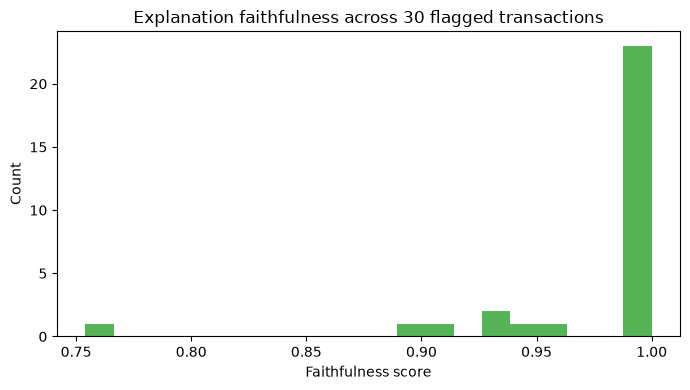

In [25]:
# Cell 22: Batch faithfulness evaluation across many flagged transactions
import time

N_EVAL = 30   # keep modest for the free-tier rate limit; raise later if smooth

records = []
for i in range(N_EVAL):
    pos = i  # positional index into the SHAP sample arrays
    proba = test_proba_cal[sample_pos[pos]]
    ctx = build_explanation_context(pos, X_sample, shap_values, feature_names, proba, best_t)
    try:
        expl = generate_explanation(ctx)
        fscore, _ = check_faithfulness(ctx, expl)
        records.append({"pos": pos, "risk_score": ctx["risk_score"],
                        "faithfulness": fscore, "explanation": expl})
    except Exception as e:
        print(f"  transaction {i}: API error -> {e}")
    time.sleep(0.5)  # gentle pacing for the free tier

faith = pd.DataFrame(records)
print(f"Evaluated {len(faith)} transactions")
print(f"Mean faithfulness:   {faith['faithfulness'].mean():.3f}")
print(f"Median faithfulness: {faith['faithfulness'].median():.3f}")
print(f"Min / Max:           {faith['faithfulness'].min():.3f} / {faith['faithfulness'].max():.3f}")
print(f"Fully faithful (=1.0): {(faith['faithfulness'] == 1.0).mean():.1%} of cases")
print()
print("Lowest-scoring cases:")
print(faith.nsmallest(3, "faithfulness")[["pos", "risk_score", "faithfulness"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(faith["faithfulness"], bins=20, color="tab:green", alpha=0.8)
ax.set_xlabel("Faithfulness score")
ax.set_ylabel("Count")
ax.set_title(f"Explanation faithfulness across {len(faith)} flagged transactions")
plt.tight_layout()
plt.show()

In [26]:
# Cell 23: Inspect the lowest-faithfulness case to characterize the failure mode
worst_pos = 18
proba_w = test_proba_cal[sample_pos[worst_pos]]
ctx_w = build_explanation_context(worst_pos, X_sample, shap_values, feature_names, proba_w, best_t)
expl_w = generate_explanation(ctx_w)
score_w, results_w = check_faithfulness(ctx_w, expl_w)

print(f"Transaction pos {worst_pos} | risk score {ctx_w['risk_score']} | decision {ctx_w['decision']}")
print(f"Faithfulness: {score_w:.3f}")
print()
print(f"{'factor':22s} {'detail':28s} {'strength':>8s}  {'dir':12s} mentioned?")
for r in results_w:
    print(f"{r['label']:22s} {str(r['detail']):28s} {r['strength']:>8.3f}  {r['direction']:12s} {r['mentioned']}")
print()
print("Explanation text:")
print(expl_w)

Transaction pos 18 | risk score 0.0349 | decision review/decline
Faithfulness: 0.852

factor                 detail                       strength  dir          mentioned?
time of day            late night (22:00-04:00)        1.495  toward_fraud True
city population        241                             1.153  toward_legit True
transaction amount     $18.27                          1.133  toward_fraud True
merchant category      personal care                   0.999  toward_legit True
month                  11                              0.940  toward_legit False
day of week            Mon                             0.619  toward_legit True

Explanation text:
The transaction was flagged for review/decline due to occurring late at night, which increases the risk of fraud, and having a transaction amount of $18.27, which also raises concerns. Although the transaction took place in a small city, at a personal care merchant, on a Monday in November, which are all factors that lower fra

In [27]:
# Cell 24: Principled fixes - drop redundant log_amt factor, make faithfulness format-aware

MONTHS = {1: "january", 2: "february", 3: "march", 4: "april", 5: "may", 6: "june",
          7: "july", 8: "august", 9: "september", 10: "october", 11: "november", 12: "december"}

def explain_transaction_v2(pos, X, shap_vals, feature_names, top_k=6, exclude=("log_amt",)):
    """Ranked SHAP breakdown, excluding redundant features (log_amt duplicates amt)."""
    row_vals = X.iloc[pos]
    row_shap = shap_vals[pos]
    contribs = []
    for name, val, sv in zip(feature_names, row_vals.values, row_shap):
        if name in exclude:
            continue
        contribs.append({"feature": name, "value": float(val), "shap": float(sv),
                         "direction": "toward_fraud" if sv > 0 else "toward_legit"})
    contribs.sort(key=lambda d: abs(d["shap"]), reverse=True)
    return contribs[:top_k]

def build_explanation_context_v2(pos, X, shap_vals, feature_names, proba, threshold, top_k=6):
    breakdown = explain_transaction_v2(pos, X, shap_vals, feature_names, top_k=top_k)
    factors = []
    for c in breakdown:
        label, detail = humanize(c["feature"], c["value"])
        factors.append({"label": label, "detail": detail,
                        "direction": c["direction"], "strength": round(abs(c["shap"]), 3),
                        "_feature": c["feature"], "_value": c["value"]})
    return {"risk_score": round(float(proba), 4), "threshold": round(float(threshold), 4),
            "decision": "review/decline" if proba >= threshold else "approve",
            "top_factors": factors}

def check_faithfulness_v2(context, explanation_text):
    text = explanation_text.lower()
    results = []
    for f in context["top_factors"]:
        cues = set()
        cues.update(f["label"].lower().split())
        cues.update(str(f["detail"]).lower().replace("$", "").replace(",", "").split())
        # Format-aware additions
        if f.get("_feature") == "month":
            cues.add(MONTHS.get(int(f["_value"]), ""))
        cues -= {"of", "the", "a", "log", "years", "(log)", ""}
        cues = {c for c in cues if len(c) > 2}
        mentioned = any(cue in text for cue in cues)
        results.append({"label": f["label"], "detail": f["detail"], "direction": f["direction"],
                        "strength": f["strength"], "mentioned": mentioned})
    total_w = sum(r["strength"] for r in results) or 1.0
    covered_w = sum(r["strength"] for r in results if r["mentioned"])
    return covered_w / total_w, results

# Re-run the batch with the corrected functions
import time
records_v2 = []
for i in range(N_EVAL):
    proba = test_proba_cal[sample_pos[i]]
    ctx = build_explanation_context_v2(i, X_sample, shap_values, feature_names, proba, best_t)
    try:
        expl = generate_explanation(ctx)
        fscore, _ = check_faithfulness_v2(ctx, expl)
        records_v2.append({"pos": i, "risk_score": ctx["risk_score"], "faithfulness": fscore})
    except Exception as e:
        print(f"  transaction {i}: API error -> {e}")
    time.sleep(0.5)

faith_v2 = pd.DataFrame(records_v2)
print(f"Evaluated {len(faith_v2)} transactions (corrected metric)")
print(f"Mean faithfulness:   {faith_v2['faithfulness'].mean():.3f}  (was 0.977)")
print(f"Median:              {faith_v2['faithfulness'].median():.3f}")
print(f"Min / Max:           {faith_v2['faithfulness'].min():.3f} / {faith_v2['faithfulness'].max():.3f}")
print(f"Fully faithful (=1.0): {(faith_v2['faithfulness'] == 1.0).mean():.1%}  (was 76.7%)")

Evaluated 30 transactions (corrected metric)
Mean faithfulness:   0.975  (was 0.977)
Median:              1.000
Min / Max:           0.754 / 1.000
Fully faithful (=1.0): 76.7%  (was 76.7%)


In [28]:
# Cell 25: Diagnose what the low-scoring explanations actually said
import time

diag = []
for i in range(N_EVAL):
    proba = test_proba_cal[sample_pos[i]]
    ctx = build_explanation_context_v2(i, X_sample, shap_values, feature_names, proba, best_t)
    try:
        expl = generate_explanation(ctx)
        fscore, results = check_faithfulness_v2(ctx, expl)
        missed = [r["label"] + "=" + str(r["detail"]) for r in results if not r["mentioned"]]
        diag.append({"pos": i, "faithfulness": fscore, "missed": missed, "explanation": expl})
    except Exception as e:
        print(f"  {i}: {e}")
    time.sleep(0.5)

diag_df = pd.DataFrame(diag)

# Show the cases that missed at least one factor
low = diag_df[diag_df["faithfulness"] < 1.0].sort_values("faithfulness")
print(f"{len(low)} of {len(diag_df)} cases missed >=1 factor\n")
for _, row in low.iterrows():
    print(f"--- pos {row['pos']}  faithfulness {row['faithfulness']:.3f}")
    print(f"    MISSED: {row['missed']}")
    print(f"    TEXT:   {row['explanation']}")
    print()

8 of 30 cases missed >=1 factor

--- pos 9  faithfulness 0.841
    MISSED: ['merchant category=shopping net']
    TEXT:   The transaction was flagged for review/decline due to a combination of factors, including the high transaction amount of $1,409.05 and the late night time of purchase. Although the cardholder's age and the small city population lowered the fraud risk, the cardholder's gender and the large transaction amount increased the risk. Overall, these factors contributed to a high fraud risk score.

--- pos 29  faithfulness 0.843
    MISSED: ['month=7', 'hour-of-day pattern=0.26']
    TEXT:   The transaction was flagged for review/decline due to its high amount of $774.23 and late night timing, which both increase the risk of fraud. However, the transaction also has some factors that lower the fraud risk, such as the merchant category and the city population. Overall, the combination of these factors led to a high fraud risk score, prompting a review/decline recommendation.



In [29]:
# Cell 26: Check what generated-explanation data is still in memory (no API calls)
candidates = ["eval_df", "diag_df", "diag", "records", "records_v2", "faith", "faith_v2"]

for name in candidates:
    if name in dir():
        obj = eval(name)
        kind = type(obj).__name__
        if hasattr(obj, "columns"):
            has_text = "explanation" in obj.columns
            print(f"{name:12s} = DataFrame, {len(obj)} rows, has 'explanation' column: {has_text}")
            if has_text:
                print(f"             columns: {list(obj.columns)}")
        elif isinstance(obj, list):
            has_text = len(obj) > 0 and isinstance(obj[0], dict) and "explanation" in obj[0]
            print(f"{name:12s} = list, {len(obj)} items, items hold 'explanation': {has_text}")
        else:
            print(f"{name:12s} = {kind}")
    else:
        print(f"{name:12s} = (not defined)")

eval_df      = (not defined)
diag_df      = DataFrame, 30 rows, has 'explanation' column: True
             columns: ['pos', 'faithfulness', 'missed', 'explanation']
diag         = list, 30 items, items hold 'explanation': True
records      = list, 30 items, items hold 'explanation': True
records_v2   = list, 30 items, items hold 'explanation': False
faith        = DataFrame, 30 rows, has 'explanation' column: True
             columns: ['pos', 'risk_score', 'faithfulness', 'explanation']
faith_v2     = DataFrame, 30 rows, has 'explanation' column: False


In [30]:
# Cell 27: Recompute faithfulness with cyclical-hour features excluded (no API calls)

def check_faithfulness_v3(context, explanation_text):
    text = explanation_text.lower()
    results = []
    for f in context["top_factors"]:
        cues = set()
        cues.update(f["label"].lower().split())
        cues.update(str(f["detail"]).lower().replace("$", "").replace(",", "").split())
        if f.get("_feature") == "month":
            cues.add(MONTHS.get(int(f["_value"]), ""))
        cues -= {"of", "the", "a", "log", "years", "(log)", ""}
        cues = {c for c in cues if len(c) > 2}
        mentioned = any(cue in text for cue in cues)
        results.append({"label": f["label"], "detail": f["detail"], "direction": f["direction"],
                        "strength": f["strength"], "mentioned": mentioned})
    total_w = sum(r["strength"] for r in results) or 1.0
    covered_w = sum(r["strength"] for r in results if r["mentioned"])
    return covered_w / total_w, results

# Exclude redundant/un-verbalizable encodings: log_amt and the cyclical hour pair
EXCLUDE = ("log_amt", "hour_sin", "hour_cos")

def build_context_v3(pos, proba):
    breakdown = explain_transaction_v2(pos, X_sample, shap_values, feature_names,
                                       top_k=6, exclude=EXCLUDE)
    factors = []
    for c in breakdown:
        label, detail = humanize(c["feature"], c["value"])
        factors.append({"label": label, "detail": detail, "direction": c["direction"],
                        "strength": round(abs(c["shap"]), 3),
                        "_feature": c["feature"], "_value": c["value"]})
    return {"risk_score": round(float(proba), 4), "threshold": round(float(best_t), 4),
            "decision": "review/decline" if proba >= best_t else "approve",
            "top_factors": factors}

# Recompute using the EXISTING explanation texts in diag_df
rescored = []
for _, row in diag_df.iterrows():
    pos = int(row["pos"])
    proba = test_proba_cal[sample_pos[pos]]
    ctx = build_context_v3(pos, proba)
    fscore, factor_results = check_faithfulness_v3(ctx, row["explanation"])
    missed = [f"{r['label']}={r['detail']}" for r in factor_results if not r["mentioned"]]
    rescored.append({"pos": pos, "faithfulness": fscore, "missed": missed})

rescored_df = pd.DataFrame(rescored)
print("Faithfulness after excluding cyclical-hour features (recomputed, no new API calls):")
print(f"  Mean:   {rescored_df['faithfulness'].mean():.3f}   (was 0.975)")
print(f"  Median: {rescored_df['faithfulness'].median():.3f}")
print(f"  Min/Max:{rescored_df['faithfulness'].min():.3f} / {rescored_df['faithfulness'].max():.3f}")
print(f"  Fully faithful: {(rescored_df['faithfulness']==1.0).mean():.1%}   (was 76.7%)")
print()
low = rescored_df[rescored_df["faithfulness"] < 1.0].sort_values("faithfulness")
print(f"Remaining {len(low)} imperfect cases (these should now be genuine omissions):")
print(low.to_string(index=False))

Faithfulness after excluding cyclical-hour features (recomputed, no new API calls):
  Mean:   0.974   (was 0.975)
  Median: 1.000
  Min/Max:0.841 / 1.000
  Fully faithful: 70.0%   (was 76.7%)

Remaining 9 imperfect cases (these should now be genuine omissions):
 pos  faithfulness                                        missed
   9      0.841072              [merchant category=shopping net]
  15      0.865962             [month=9, city population=19,090]
  29      0.867449                [month=7, cardholder gender=F]
   5      0.909270                                     [month=8]
  28      0.920442 [city population=10,076, cardholder gender=F]
  13      0.935492                             [day of week=Sun]
  25      0.941410                                     [month=7]
  26      0.954202               [merchant category=food dining]
  19      0.975232                      [city population=19,090]


In [31]:
# Cell 28: Persist the final faithfulness evaluation (no API calls)
import json
from pathlib import Path

MODELS_DIR = Path("../models")

# Merge stored explanations with the corrected (v3) scores
final_eval = diag_df[["pos", "explanation"]].merge(rescored_df, on="pos")
final_eval = final_eval[["pos", "faithfulness", "missed", "explanation"]]
final_eval.to_csv(MODELS_DIR / "faithfulness_eval.csv", index=False)

summary = {
    "n_evaluated": int(len(rescored_df)),
    "mean_faithfulness": round(float(rescored_df["faithfulness"].mean()), 4),
    "median_faithfulness": round(float(rescored_df["faithfulness"].median()), 4),
    "min_faithfulness": round(float(rescored_df["faithfulness"].min()), 4),
    "pct_fully_faithful": round(float((rescored_df["faithfulness"] == 1.0).mean()), 4),
    "excluded_features": list(EXCLUDE),
    "llm_provider": "Groq",
    "llm_model": GROQ_MODEL,
    "note": "Lexical faithfulness metric; remaining sub-1.0 cases are omissions of low-strength factors, not fabrications.",
}
with open(MODELS_DIR / "faithfulness_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved faithfulness_eval.csv and faithfulness_summary.json to", MODELS_DIR.resolve())
print(json.dumps(summary, indent=2))

Saved faithfulness_eval.csv and faithfulness_summary.json to D:\My Documents\Northeastern Summer Semester\Machine Learning Final Project\Payment Risk Engine\models
{
  "n_evaluated": 30,
  "mean_faithfulness": 0.9737,
  "median_faithfulness": 1.0,
  "min_faithfulness": 0.8411,
  "pct_fully_faithful": 0.7,
  "excluded_features": [
    "log_amt",
    "hour_sin",
    "hour_cos"
  ],
  "llm_provider": "Groq",
  "llm_model": "llama-3.3-70b-versatile",
  "note": "Lexical faithfulness metric; remaining sub-1.0 cases are omissions of low-strength factors, not fabrications."
}


In [32]:
# Cell 29: Save the raw XGBoost model for SHAP use in the app
import joblib
from pathlib import Path

MODELS_DIR = Path("../models")
joblib.dump(xgb, MODELS_DIR / "xgb_raw.joblib")

p = MODELS_DIR / "xgb_raw.joblib"
print(f"Saved {p.name}: {p.stat().st_size/1024:,.1f} KB")

# Confirm the models folder now has everything the app needs
print("\nmodels/ contents:")
for f in sorted(MODELS_DIR.iterdir()):
    print(f"  {f.name:28s} {f.stat().st_size/1024:,.1f} KB")

Saved xgb_raw.joblib: 1,479.6 KB

models/ contents:
  calibrated_xgb.joblib        1,463.2 KB
  faithfulness_eval.csv        13.3 KB
  faithfulness_summary.json    0.4 KB
  feature_columns.json         0.4 KB
  operating_point.json         0.3 KB
  xgb_raw.joblib               1,479.6 KB


In [35]:
import sys
# Drop any cached copy so Python re-reads the file from disk
sys.modules.pop("risk_engine", None)

import importlib
import risk_engine
importlib.reload(risk_engine)

print("ROOT attr present:", hasattr(risk_engine, "ROOT"))
print("Loaded from file:", risk_engine.__file__)
if hasattr(risk_engine, "ROOT"):
    print("Module ROOT:", risk_engine.ROOT)
    print("MODELS_DIR exists:", risk_engine.MODELS_DIR.exists())
    print("Sees calibrated model:", (risk_engine.MODELS_DIR / "calibrated_xgb.joblib").exists())

ROOT attr present: True
Loaded from file: d:\My Documents\Northeastern Summer Semester\Machine Learning Final Project\Payment Risk Engine\src\risk_engine.py
Module ROOT: D:\My Documents\Northeastern Summer Semester\Machine Learning Final Project\Payment Risk Engine
MODELS_DIR exists: True
Sees calibrated model: True


In [36]:
# Cell 30: End-to-end test of the module on one raw transaction (one API call)
importlib.reload(risk_engine)  # pick up the saved file

calibrated, xgb_raw, operating, feature_columns = risk_engine.load_artifacts()
threshold = operating["threshold"]
client = risk_engine.get_groq_client()

# A realistic raw transaction (fraud-like: large amount, late night, online shopping)
raw_txn = {
    "trans_date_trans_time": "2020-06-15 23:14:00",
    "amt": 899.99,
    "category": "shopping_net",
    "gender": "F",
    "city_pop": 120000,
    "dob": "1991-04-02",
}

result = risk_engine.score_transaction(
    raw_txn, calibrated, xgb_raw, feature_columns, threshold, client, explain=True
)

print(f"Risk score:   {result['risk_score']}  (threshold {result['threshold']})")
print(f"Decision:     {result['decision']}")
print(f"Faithfulness: {result['faithfulness']}")
print()
print("Explanation:")
print(result["explanation"])
print()
print("Top factors:")
for f in result["context"]["top_factors"]:
    arrow = "UP  " if f["direction"] == "toward_fraud" else "down"
    print(f"  [{arrow}] {f['label']}: {f['detail']}  (strength {f['strength']})")

Risk score:   0.0594  (threshold 0.029)
Decision:     review/decline
Faithfulness: 1.0

Explanation:
The transaction was flagged for review/decline due to its high amount of $899.99 and the late night timing, which both increase the risk of fraud. However, the cardholder's age, the merchant category, the city population, and the month of the transaction all suggest lower fraud risk. Overall, the high transaction amount and late night timing were enough to outweigh the other factors and trigger a review/decline recommendation.

Top factors:
  [UP  ] transaction amount: $899.99  (strength 4.629)
  [down] merchant category: shopping net  (strength 1.969)
  [down] cardholder age: 29 years  (strength 1.363)
  [UP  ] time of day: late night (22:00-04:00)  (strength 0.952)
  [down] city population: 120,000  (strength 0.927)
  [down] month: 6  (strength 0.553)
